In [1]:
# ========================
# Import Libraries
# ========================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [3]:
# ========================
#  Load Dataset
# ========================

In [4]:
file_path = "Snitch_Fashion_Sales_Uncleaned.csv"
df = pd.read_csv(file_path)
df.head()

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66


In [5]:
# ========================
#  Missing Values Check
# ========================

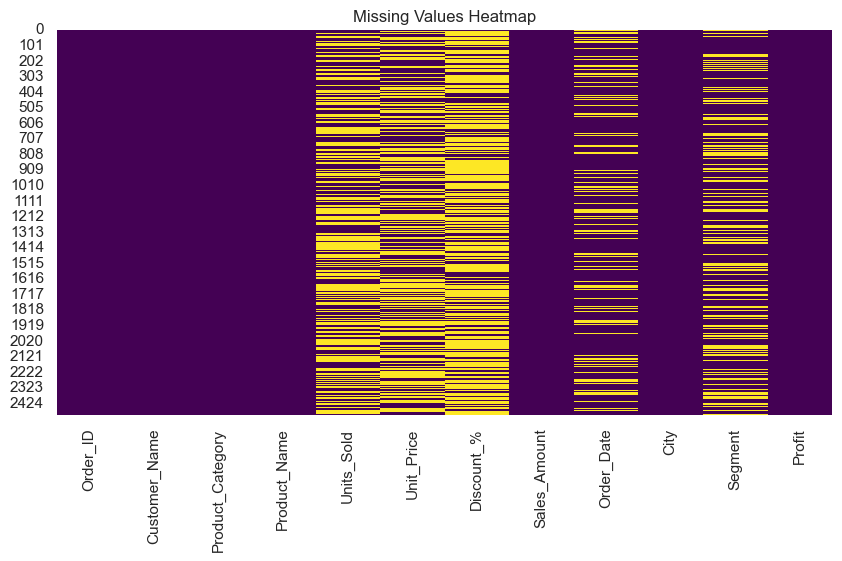

Order_ID               0
Customer_Name          0
Product_Category       0
Product_Name           0
Units_Sold          1306
Unit_Price          1210
Discount_%          1651
Sales_Amount           0
Order_Date           606
City                   0
Segment              821
Profit                 0
dtype: int64

In [6]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()
df.isnull().sum()


In [7]:
# ========================
#  Fill Missing Values
# ========================


In [8]:
num_cols = ["Units_Sold", "Unit_Price", "Discount_%", "Sales_Amount", "Profit"]
cat_cols = ["Order_Date", "Segment"]

num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df.isnull().sum()

Order_ID            0
Customer_Name       0
Product_Category    0
Product_Name        0
Units_Sold          0
Unit_Price          0
Discount_%          0
Sales_Amount        0
Order_Date          0
City                0
Segment             0
Profit              0
dtype: int64

In [9]:
# ========================
#  EDA - Numerical Distribution
# ========================


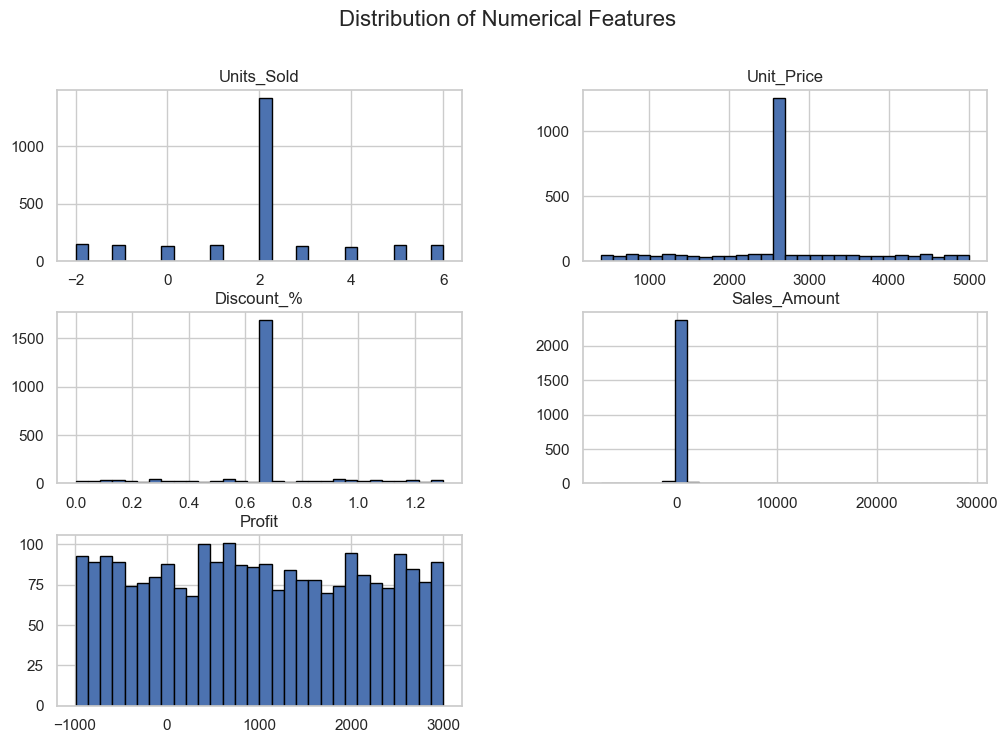

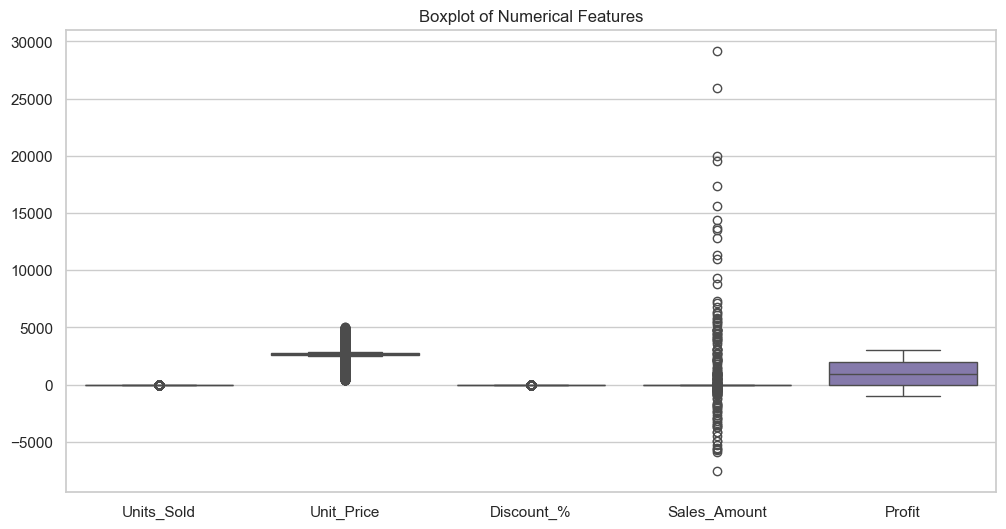

In [10]:
df[num_cols].hist(figsize=(12,8), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot of Numerical Features")
plt.show()


In [11]:
# ========================
#  EDA - Categorical Analysis
# ========================


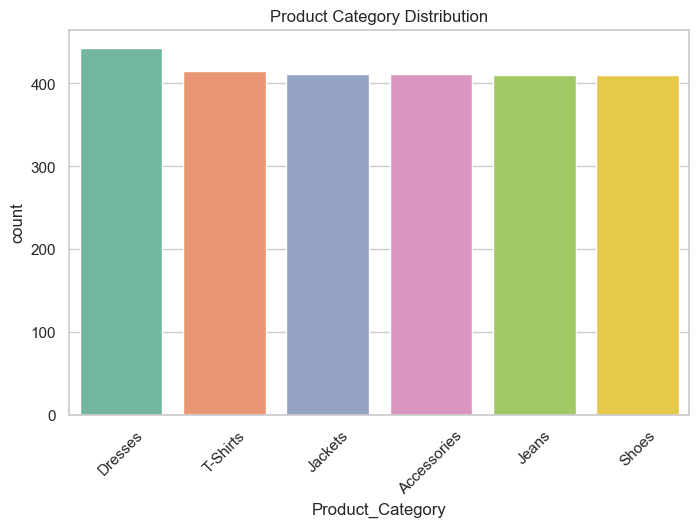

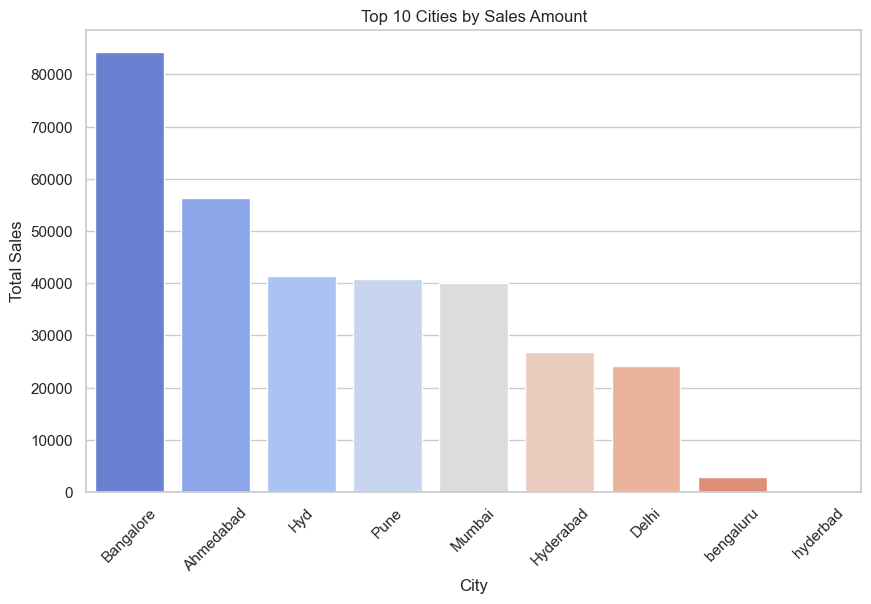

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Product_Category", 
              order=df["Product_Category"].value_counts().index, palette="Set2")
plt.title("Product Category Distribution")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,6))
city_sales = df.groupby("City")["Sales_Amount"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=city_sales.index, y=city_sales.values, palette="coolwarm")
plt.title("Top 10 Cities by Sales Amount")
plt.xticks(rotation=45)
plt.ylabel("Total Sales")
plt.show()


In [13]:
# ========================
#  Sales vs Profit
# ========================


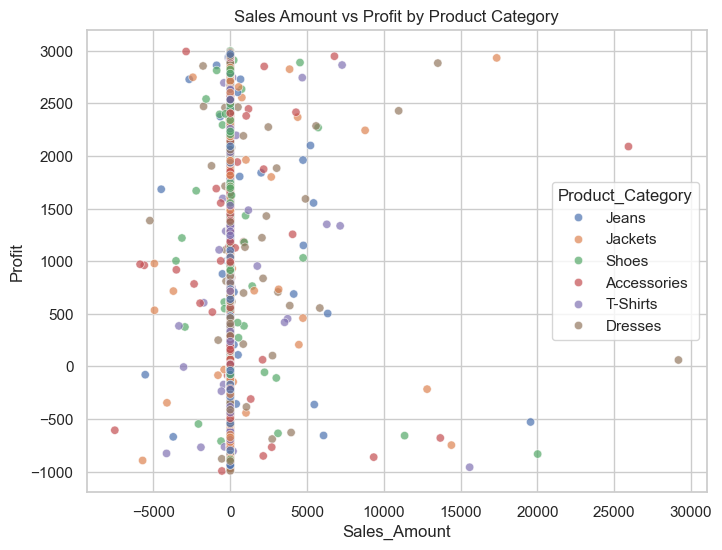

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Sales_Amount", y="Profit", hue="Product_Category", alpha=0.7)
plt.title("Sales Amount vs Profit by Product Category")
plt.show()


In [15]:
# ========================
#  K-Means Clustering
# ========================

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


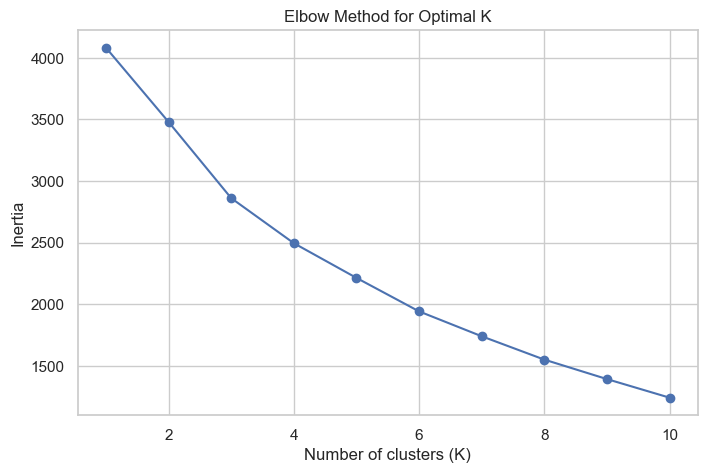

In [16]:
features = df[num_cols]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Elbow Method (sample for speed)
sample_data = scaled_features[np.random.choice(scaled_features.shape[0], 800, replace=False)]

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(sample_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [17]:
# ========================
#  Final Clustering
# ========================


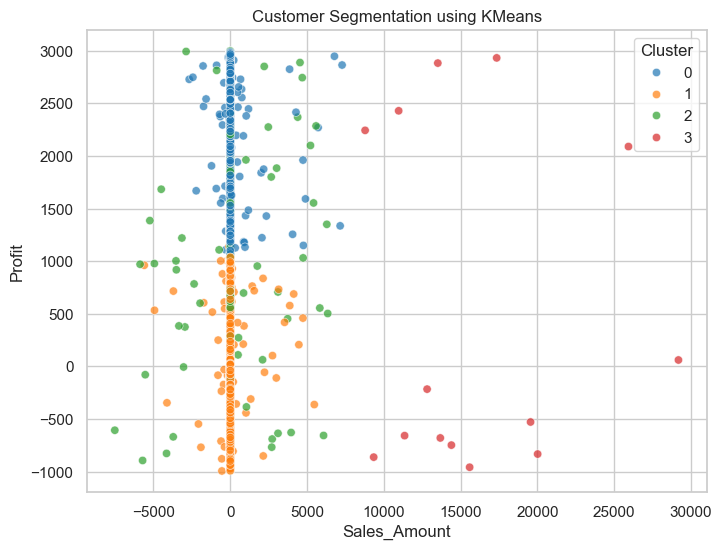

,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Profit
Cluster,,,,,
0,1.985968,2728.034434,0.702133,51.871469,2043.279289
1,2.016594,2665.024118,0.708803,15.592856,31.915380
2,1.569853,2562.755717,0.209301,77.748015,830.711801
3,5.000000,4111.707143,0.207857,15888.482143,511.450000


In [18]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_features)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Sales_Amount", y="Profit", hue="Cluster", palette="tab10", alpha=0.7)
plt.title("Customer Segmentation using KMeans")
plt.show()

# Cluster wise average values
df.groupby("Cluster")[num_cols].mean()

In [19]:
# ========================
#  Silhouette Method
# ========================

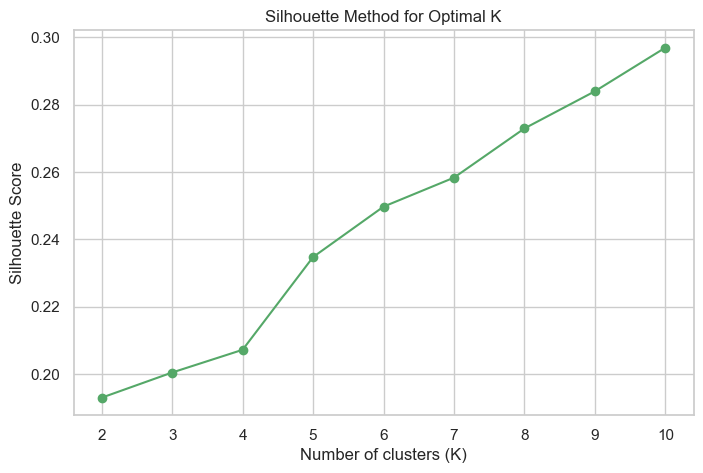

In [20]:
silhouette_scores = []
K = range(2, 11)  # silhouette is not defined for k=1
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sample_data)
    score = silhouette_score(sample_data, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, 'go-')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal K")
plt.show()
